In [1]:
!pip install datasets nltk pandas numpy

In [2]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset(
    "ai4bharat/IndicCorpV2",
    streaming=True
)

languages = list(dataset.keys())

print("Total Languages:", len(languages))
print(languages)

README.md:   0%|          | 0.00/4.01k [00:00<?, ?B/s]

Total Languages: 23
['asm_Beng', 'ben_Beng', 'brx_Deva', 'doi_Deva', 'gom_Deva', 'guj_Gujr', 'hin_Deva', 'kan_Knda', 'kas_Arab', 'mai_Deva', 'mal_Mlym', 'mar_Deva', 'mni_Mtei', 'npi_Deva', 'ory_Orya', 'pan_Guru', 'san_Deva', 'snd_Deva', 'tam_Taml', 'tel_Telu', 'urd_Arab', 'khasi', 'santhali']


In [3]:
samples_per_language = 1000

data = []

for lang in languages:

    print("Processing:", lang)

    count = 0

    for row in dataset[lang]:

        # Check actual column names
        text = str(list(row.values())[0]).strip()

        if len(text.split()) < 3:
            continue

        data.append({
            "sentence": text,
            "label": lang
        })

        count += 1

        if count >= samples_per_language:
            break

    print(f"{lang}: {count}")

Processing: asm_Beng
asm_Beng: 1000
Processing: ben_Beng
ben_Beng: 1000
Processing: brx_Deva
brx_Deva: 1000
Processing: doi_Deva
doi_Deva: 1000
Processing: gom_Deva
gom_Deva: 1000
Processing: guj_Gujr
guj_Gujr: 1000
Processing: hin_Deva
hin_Deva: 1000
Processing: kan_Knda
kan_Knda: 1000
Processing: kas_Arab
kas_Arab: 1000
Processing: mai_Deva
mai_Deva: 1000
Processing: mal_Mlym
mal_Mlym: 1000
Processing: mar_Deva
mar_Deva: 1000
Processing: mni_Mtei
mni_Mtei: 1000
Processing: npi_Deva
npi_Deva: 1000
Processing: ory_Orya
ory_Orya: 1000
Processing: pan_Guru
pan_Guru: 1000
Processing: san_Deva
san_Deva: 1000
Processing: snd_Deva
snd_Deva: 1000
Processing: tam_Taml
tam_Taml: 1000
Processing: tel_Telu
tel_Telu: 1000
Processing: urd_Arab
urd_Arab: 1000
Processing: khasi
khasi: 1000
Processing: santhali
santhali: 1000


In [4]:
df = pd.DataFrame(data)

print(df.shape)
print(df["label"].value_counts())

(23000, 2)
label
asm_Beng    1000
ben_Beng    1000
brx_Deva    1000
doi_Deva    1000
gom_Deva    1000
guj_Gujr    1000
hin_Deva    1000
kan_Knda    1000
kas_Arab    1000
mai_Deva    1000
mal_Mlym    1000
mar_Deva    1000
mni_Mtei    1000
npi_Deva    1000
ory_Orya    1000
pan_Guru    1000
san_Deva    1000
snd_Deva    1000
tam_Taml    1000
tel_Telu    1000
urd_Arab    1000
khasi       1000
santhali    1000
Name: count, dtype: int64


In [5]:
df.to_csv("indic23_languages.csv", index=False)

In [6]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(18400, 2)
(2300, 2)
(2300, 2)


In [7]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("validation.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [8]:
!mv "/content/indic23_languages.csv" "/content/drive/MyDrive/Colab Notebooks/ILLM/"

In [9]:
def extract_features(sentence):

    words = sentence.split()

    features = []

    # Unigrams
    features.extend(words)

    # Bigrams
    for i in range(len(words)-1):
        features.append(words[i] + "_" + words[i+1])

    text = sentence.replace(" ", "")

    # Character n-grams
    for n in [2,3,4]:
        for i in range(len(text)-n+1):
            features.append(text[i:i+n])

    return features

In [10]:
import math
import numpy as np

from collections import Counter
from collections import defaultdict

from scipy.sparse import csr_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [11]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(18400, 2)
(2300, 2)
(2300, 2)


In [12]:
train_sentences = train_df["sentence"].tolist()
val_sentences = val_df["sentence"].tolist()
test_sentences = test_df["sentence"].tolist()

y_train = train_df["label"]
y_val = val_df["label"]
y_test = test_df["label"]

In [13]:
document_frequency = defaultdict(int)

for sentence in train_sentences:

    features = extract_features(sentence)

    unique_features = set(features)

    for feature in unique_features:
        document_frequency[feature] += 1

vocabulary = {
    feature: idx
    for idx, feature
    in enumerate(document_frequency.keys())
}

print("Vocabulary Size:", len(vocabulary))

Vocabulary Size: 2246636


In [14]:
N = len(train_sentences)

idf = {}

for feature, df in document_frequency.items():

    idf[feature] = (
        math.log(
            N / (df + 1)
        ) + 1
    )

print("IDF Computed")

IDF Computed


In [15]:
max_idf = max(idf.values())

idf_normalized = {}

for feature, value in idf.items():

    idf_normalized[feature] = (
        value / max_idf
    )

print("Normalized IDF Computed")

Normalized IDF Computed


In [16]:
def tf_unnormalized(features):

    return dict(
        Counter(features)
    )

In [17]:
def tf_total_words(
    sentence,
    features
):

    counts = Counter(features)

    total_words = len(
        sentence.split()
    )

    tf = {}

    for feature, count in counts.items():

        tf[feature] = (
            count / total_words
        )

    return tf

In [18]:
def tf_max_frequency(features):

    counts = Counter(features)

    max_frequency = max(
        counts.values()
    )

    tf = {}

    for feature, count in counts.items():

        tf[feature] = (
            count / max_frequency
        )

    return tf

In [19]:
print("Vocabulary Size:", len(vocabulary))

Vocabulary Size: 2246636


In [20]:
feature_frequency = defaultdict(int)

for sentence in train_sentences:

    features = extract_features(sentence)

    for feature in features:
        feature_frequency[feature] += 1

In [21]:
MIN_FREQ = 5

vocabulary = {}

index = 0

for feature, freq in feature_frequency.items():

    if freq >= MIN_FREQ:

        vocabulary[feature] = index

        index += 1

print("Vocabulary Size:", len(vocabulary))

Vocabulary Size: 298843


In [22]:
document_frequency = defaultdict(int)

for sentence in train_sentences:

    features = extract_features(sentence)

    unique_features = set(features)

    for feature in unique_features:

        if feature in vocabulary:

            document_frequency[feature] += 1

In [23]:
N = len(train_sentences)

idf = {}

for feature, df in document_frequency.items():

    idf[feature] = (
        math.log(
            N / (df + 1)
        ) + 1
    )

In [24]:
MIN_FREQ = 5
...
print("Vocabulary Size:", len(vocabulary))

Vocabulary Size: 298843


In [25]:
N = len(train_sentences)

idf = {}

for feature, df in document_frequency.items():

    idf[feature] = (
        math.log(
            N / (df + 1)
        ) + 1
    )

print("IDF Computed")

IDF Computed


In [26]:
max_idf = max(idf.values())

idf_normalized = {}

for feature, value in idf.items():

    idf_normalized[feature] = (
        value / max_idf
    )

print("Normalized IDF Computed")

Normalized IDF Computed


In [27]:
def build_matrix(
    sentences,
    tf_type,
    idf_dict
):

    rows = []
    cols = []
    values = []

    for row_idx, sentence in enumerate(sentences):

        features = extract_features(sentence)

        # TF Selection

        if tf_type == "unnormalized":

            tf_values = tf_unnormalized(
                features
            )

        elif tf_type == "total_words":

            tf_values = tf_total_words(
                sentence,
                features
            )

        else:

            tf_values = tf_max_frequency(
                features
            )

        for feature, tf_value in tf_values.items():

            if feature not in vocabulary:
                continue

            col_idx = vocabulary[feature]

            tfidf = (
                tf_value *
                idf_dict[feature]
            )

            rows.append(row_idx)
            cols.append(col_idx)
            values.append(tfidf)

    matrix = csr_matrix(
        (
            values,
            (rows, cols)
        ),
        shape=(
            len(sentences),
            len(vocabulary)
        ),
        dtype=np.float32
    )

    return matrix

In [28]:
X_train = build_matrix(
    train_sentences,
    "unnormalized",
    idf
)

X_test = build_matrix(
    test_sentences,
    "unnormalized",
    idf
)

print(X_train.shape)
print(X_test.shape)

(18400, 298843)
(2300, 298843)


In [29]:
model = LogisticRegression(
    max_iter=500,
    solver="saga",
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=500, n_jobs=-1, solver='saga')

In [30]:
predictions = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.8682608695652174


In [34]:
def run_experiment(tf_type, idf_dict):

    X_train = build_matrix(
        train_sentences,
        tf_type,
        idf_dict
    )

    X_test = build_matrix(
        test_sentences,
        tf_type,
        idf_dict
    )

    model = LogisticRegression(
        max_iter=500,
        solver="saga",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        preds
    )

    return acc

In [35]:
results = []

results.append([
    "TF Unnormalized + IDF Unnormalized",
    run_experiment("unnormalized", idf)
])

results.append([
    "TF Unnormalized + IDF Normalized",
    run_experiment("unnormalized", idf_normalized)
])

results.append([
    "TF TotalWords + IDF Unnormalized",
    run_experiment("total_words", idf)
])

results.append([
    "TF TotalWords + IDF Normalized",
    run_experiment("total_words", idf_normalized)
])

results.append([
    "TF MaxFreq + IDF Unnormalized",
    run_experiment("max_frequency", idf)
])

results.append([
    "TF MaxFreq + IDF Normalized",
    run_experiment("max_frequency", idf_normalized)
])

for r in results:
    print(r)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


['TF Unnormalized + IDF Unnormalized', 0.8682608695652174]
['TF Unnormalized + IDF Normalized', 0.8682608695652174]
['TF TotalWords + IDF Unnormalized', 0.9617391304347827]
['TF TotalWords + IDF Normalized', 0.9552173913043478]
['TF MaxFreq + IDF Unnormalized', 0.9586956521739131]
['TF MaxFreq + IDF Normalized', 0.957391304347826]


In [36]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Combination", "Accuracy"]
)

results_df["Accuracy (%)"] = (
    results_df["Accuracy"] * 100
).round(2)

print(results_df.to_string(index=False))

                       Combination  Accuracy  Accuracy (%)
TF Unnormalized + IDF Unnormalized  0.868261         86.83
  TF Unnormalized + IDF Normalized  0.868261         86.83
  TF TotalWords + IDF Unnormalized  0.961739         96.17
    TF TotalWords + IDF Normalized  0.955217         95.52
     TF MaxFreq + IDF Unnormalized  0.958696         95.87
       TF MaxFreq + IDF Normalized  0.957391         95.74


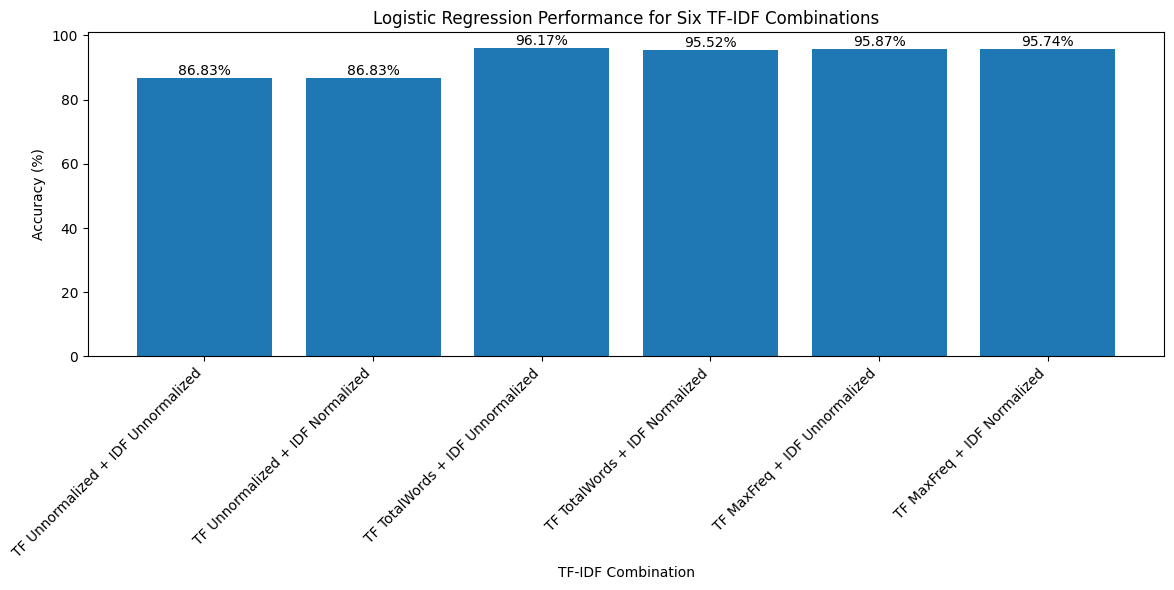

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

bars = plt.bar(
    results_df["Combination"],
    results_df["Accuracy (%)"]
)

plt.xlabel("TF-IDF Combination")
plt.ylabel("Accuracy (%)")
plt.title("Logistic Regression Performance for Six TF-IDF Combinations")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, accuracy in zip(
    bars,
    results_df["Accuracy (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{accuracy:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [38]:
best_result = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Best Combination:")
print(best_result["Combination"])

print("Best Accuracy:")
print(best_result["Accuracy (%)"], "%")

Best Combination:
TF TotalWords + IDF Unnormalized
Best Accuracy:
96.17 %


In [39]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Combination", "Accuracy"]
)

results_df["Accuracy (%)"] = (
    results_df["Accuracy"] * 100
).round(2)

results_df.to_csv(
    "tfidf_results.csv",
    index=False
)

print("Results saved successfully!")
print(results_df)

Results saved successfully!
                          Combination  Accuracy  Accuracy (%)
0  TF Unnormalized + IDF Unnormalized  0.868261         86.83
1    TF Unnormalized + IDF Normalized  0.868261         86.83
2    TF TotalWords + IDF Unnormalized  0.961739         96.17
3      TF TotalWords + IDF Normalized  0.955217         95.52
4       TF MaxFreq + IDF Unnormalized  0.958696         95.87
5         TF MaxFreq + IDF Normalized  0.957391         95.74


In [40]:
!cp "/content/tfidf_results.csv" "/content/drive/MyDrive/Colab Notebooks/ILLM"